In [1]:
# # download the artbench dataset
# import wget
# wget.download(url="https://artbench.eecs.berkeley.edu/files/artbench-10-imagefolder-split.tar",
#               out = 'C:/Users/dorok/Desktop/chatGPT/Diffusion model/art')

# # Uncompress the tar file
# import tarfile
# file = tarfile.open("C:/Users/dorok/Desktop/chatGPT/Diffusion model/art/artbench-10-imagefolder-split.tar")
# file.extractall('C:/Users/dorok/Desktop/chatGPT/Diffusion model/art')
# file.close()  
#!pip install torchvision --upgrade

In [1]:
# InitialDir = 'D:/pet-radiomics-challenges/Training/Training/HN-MICCAI2018-0004/'
# import matplotlib.pyplot as plt
# import pydicom
# import os

# # Open the DICOM file
# TrainingDir = "D:/pet-radiomics-challenges/Training/Training/"
# Directories = os.listdir(TrainingDir)

# Directory = -1
# Images = os.listdir(TrainingDir+Directories[Directory])
# for i in range(0,10):
#     dicom_file = pydicom.dcmread(TrainingDir+Directories[Directory]+"/"+Images[i])
#     image = dicom_file.pixel_array

#     # Show the image
#     plt.imshow(image)
#     plt.show()

In [2]:
# InitialDir = 'D:/pet-radiomics-challenges/Test/Test/HN-MICCAI2018-0004/'
# import matplotlib.pyplot as plt
# import pydicom
# import os

# # Open the DICOM file
# TrainingDir = "D:/pet-radiomics-challenges/Test/Test/"
# Directories = os.listdir(TrainingDir)

# Directory = -1
# Images = os.listdir(TrainingDir+Directories[Directory])
# for i in range(0,10):
#     dicom_file = pydicom.dcmread(TrainingDir+Directories[Directory]+"/"+Images[i])
#     image = dicom_file.pixel_array

#     # Show the image
#     plt.imshow(image)
#     plt.show()

In [11]:
#!/usr/bin/python

import sys
import getopt
import nibabel as nib
import numpy
import scipy

# params is the dictionary holding all needed parameters for the script
# think about adding an -m option for introducing a mask
params = {
    'nii_filename': "",
    'start_slice': 0,
    'end_slice': None,
    'alternate_slice': 1,
    'plane': "ax",
    'output_prefix': "img",
    'format': "png",
    'verbose': False
}


def parse_params(argv, params):
    if not argv:
        print_help()
        sys.exit(0)

    try:
        short_opts = "s:e:a:p:o:f:vh"
        long_opts = ["start_slice=", "end_slice=", "alternate_slice=", "plane=", "output_prefix=", "format=", "verbose", "help"]
        opts, args = getopt.getopt(argv, short_opts, long_opts)
        if len(args) == 1:
            params['nii_filename'] = args[0]
        elif len(args) > 1:
            raise

    except:
        print ("Error! Invalid option(s)")
        sys.exit(2)

    for opt, arg in opts:
        if opt in ("-s", "--start_slice"):
            params['start_slice'] = int(arg)
        elif opt in ("-e", "--end_slice"):
            params['end_slice'] = int(arg)
        elif opt in ("-a", "--alternate_slice"):
            params['alternate_slice'] = int(arg)
        elif opt in ("-p", "--plane'"):
            params['plane'] = arg
        elif opt in ("-o", "--output_prefix"):
            params['output_prefix'] = arg
        elif opt in ("-v", "--verbose"):
            params['verbose'] = True
        elif opt in ("-f", "--format"):
            params['format'] = arg
        elif opt in ("-h", "--help"):
            print_help()
            sys.exit(0)


def print_help():
    print ("")
    print ("nii2img.py [OPTION] [NIFTI_INPUT_FILE]")
    print ("The NIFTI_INPUT_FILE must be in LAS orientation!")
    print ("Available command line options:")
    print ("-s, --start_slice")
    print ("-e, --end_slice")
    print ("-a, --alternate_slice")
    print ("-p, --plane : extract images in axial (ax), coronar (cor) or sagittal (sag) plane")
    print ("-o, --output_prefix")
    print ("-f, --format : output format (png by default); png, jpg, bmp")
    print ("-v, --verbose")
    print( "-h, --help")
    print ("")


# load nifti file according to parameters above
def load_nii(params):
    if not params['nii_filename']:
        print ("Error! Missing NIFTI input file.")
        sys.exit(2)

    if params['verbose']:
        print ("Loading NIfTI file")

    img = nib.load(params['nii_filename'])
    data = img.get_data()
    return data


# normalize the color value range in the original nii image
def normalize_nii(params, data):
    if params['verbose']:
        print( "Normalizing intensities")


# extract the images from the file you wish to continue with, alternation, start and end slice
def extract_img(params, data):
    if params['verbose']:
        print ("Extracting images")

    image_counter = 0
    slice_counter = 0
    start_slice = params['start_slice'] or 0
    start_slice = start_slice - 1 if start_slice > 0 else start_slice
    end_slice = params['end_slice'] or data.shape[2]
    for i in range(start_slice, end_slice):
        if (slice_counter % params['alternate_slice']) == 0:
            if params['plane'] == "ax":
                slice = data[:, :, i]
            elif params['plane'] == "cor":
                slice = data[:, i, :]
            elif params['plane'] == "sag":
                slice = data[i, :, :]

            slice = numpy.rot90(slice)

            image_name = params['output_prefix'] + str(image_counter) + "." + params['format']
            scipy.misc.imsave(image_name, slice)
            image_counter += 1
            if params['verbose']:
                sys.stdout.write(".")
                sys.stdout.flush()
        slice_counter += 1

    if params['verbose']:
        print ("")


if __name__ == '__main__':
    parse_params(sys.argv[1:], params)
    data = load_nii(params)
    normalize_nii(params, data)
    extract_img(params, data)
    if params['verbose']:
        print ("Finished")


Error! Missing NIFTI input file.


SystemExit: 2

d:\Conda\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [2]:
!conda install git+https://github.com/NiftyPET/NIMPA.git

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: failed



PackagesNotFoundError: The following packages are not available from current channels:

  - //github.com/niftypet/nimpa.git

Current channels:

  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [11]:
!conda install opencv-python

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: failed



PackagesNotFoundError: The following packages are not available from current channels:

  - opencv-python

Current channels:

  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [15]:
import os
print(len(os.listdir("D:/pet-radiomics-challenges/DatasetX/TrainingImages/")))
print(len(os.listdir("D:/pet-radiomics-challenges/DatasetY/TrainingImages/")))

1515
1517


In [47]:
import os
print(len(os.listdir(r"D:\New folder\FDG-PET-CT-Lesions/")))

244


d:\Conda\Lib\site-packages\miutil\cuinfo.py:12: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


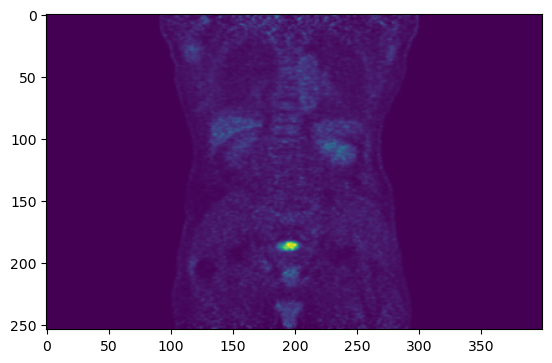

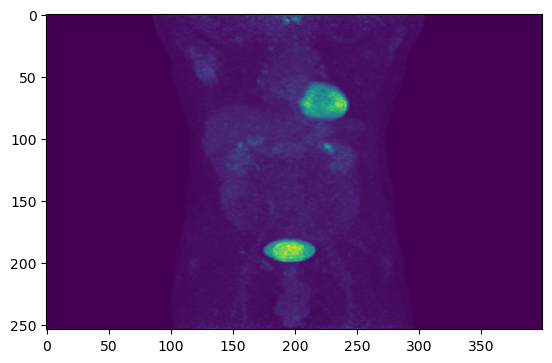

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from niftypet import nimpa
import os
import pydicom as dicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import numpy as np
import cv2


filename = "PET.nii.gz"
dirs = os.listdir(r"D:\New folder\FDG-PET-CT-Lesions/")
#TrainDest = 'C:/Users/dorok/Downloads/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/'
#im = nimpa.getnii('C:/Users/dorok/Downloads/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/'+filename)#[:,70,:]
directory = r"D:\New folder\FDG-PET-CT-Lesions/"+dirs[0]
dirofDir = os.listdir(r"D:\New folder\FDG-PET-CT-Lesions/"+dirs[0])[0]
im = nimpa.getnii(directory+"/"+dirofDir+"/"+filename)
maximum = np.max(im,axis=1)
coronal = []
for i in range(0,400):
    coronal.append(im[:,i,:])

plt.imshow(coronal[220])
plt.show()
plt.imshow(maximum)



224


AttributeError: module 'matplotlib.pyplot' has no attribute 'spines'

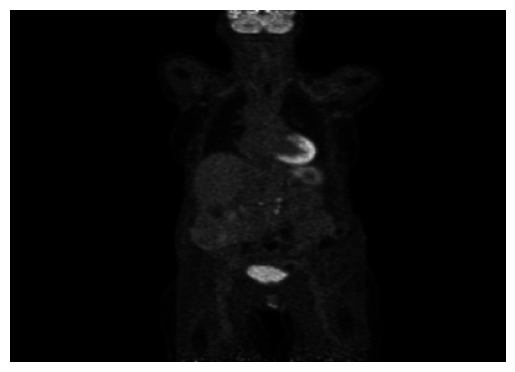

: 

In [ ]:
import numpy as np
from niftypet import nimpa
import os
import cv2
import scipy
def mip_index(volume, axis):
    # Sum intensity over the other two dimensions
    sums = np.sum(volume, axis=tuple(a for a in range(3) if a != axis))
    return int(np.argmax(sums))

InitialDirectory = r"D:\New folder\FDG-PET-CT-Lesions/"
imageindx = 100
for i in range(imageindx,imageindx+1):
#for i in range(0,1):
    NextDir = os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]
    nii_path = r"D:\New folder\FDG-PET-CT-Lesions/"+"/"+os.listdir(InitialDirectory)[i]+"/"+NextDir+"\PET.nii.gz"
    im = nimpa.getnii(nii_path)      # shape: (X,Y,Z)
    idx_y = mip_index(im, axis=1)   # coronal slices
    print(idx_y)

NextDir = os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]
nii_path = r"D:\New folder\FDG-PET-CT-Lesions/"+"/"+os.listdir(InitialDirectory)[i]+"/"+NextDir+"\PET.nii.gz"
im = nimpa.getnii(nii_path)      # shape: (X,Y,Z)
import matplotlib.pyplot as plt
plt.imshow(im[:,idx_y,:])
TrainDest = 'D:/New folder/DatasetX/Training/'
image = cv2.imread(str(TrainDest+(os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]+str(idx_y)+".jpg")))
plt.imshow(image,interpolation=None)
plt.axis(False)
plt.spines['top'].set_visible(False)
plt.spines['right'].set_visible(False)
plt.spines['bottom'].set_visible(False)
plt.spines['left'].set_visible(False)
plt.savefig("TestImage.jpg")
plt.show()
# Source - https://stackoverflow.com/a
# Posted by Kallz, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-30, License - CC BY-SA 3.0

import cv2
filename = str(TrainDest+(os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]+str(idx_y)+".jpg"))

image = cv2.imread(filename) 

small = cv2.resize(image, (0,0), fx=0.5, fy=0.5) 

large = cv2.resize(image, (0,0), fx=1.5, fy=1.5)


crop_img = small[0:128, 0:128] # Crop from {x, y, w, h } => {0, 0, 300, 400}

#plt.imshow(crop_img)
#plt.show()


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from niftypet import nimpa
import os
import pydicom as dicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import numpy as np
import cv2
def mip_index(volume, axis):
    # Sum intensity over the other two dimensions
    sums = np.sum(volume, axis=tuple(a for a in range(3) if a != axis))
    return int(np.argmax(sums))
InitialDirectory = r"D:\New folder\FDG-PET-CT-Lesions/"
for i in range(0,int(len(os.listdir(InitialDirectory))/2)):
#for i in range(0,1):
    NextDir = os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]
    nii_path = r"D:\New folder\FDG-PET-CT-Lesions/"+"/"+os.listdir(InitialDirectory)[i]+"/"+NextDir+"\PET.nii.gz"
    im = nimpa.getnii(nii_path)      # shape: (X,Y,Z)
    idx_y = mip_index(im, axis=1)   # coronal slices
    for j in range(idx_y-10,idx_y+20):
        #im[j]
        TrainDest = 'D:/New folder/DatasetX/Training/'
        image_path = nii_path#.replace(".nii.gz","")
        image_path = image_path.replace('.nii.gz', ".jpg")
        image_format = ".jpg"
        #print(image_path)
        #norm = cv2.normalize(im, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
        norm = (im[:,j,:] - np.min(im[:,j,:])) / (np.max(im[:,j,:]) - np.min(im[:,j,:]))*350
        
        cv2.imwrite(image_path, norm)

        os.replace((image_path), TrainDest+(os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]+str(j)+".jpg"))
        
        




d:\Conda\Lib\site-packages\miutil\cuinfo.py:12: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


KeyboardInterrupt: 

In [2]:
TrainDest = 'D:/New folder/Testing/'
image_path = nii_path#.replace(".nii.gz","")
image_path = image_path.replace('.nii.gz', ".jpg")
image_format = ".jpg"
NextDir = os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]
Name = "CT"
nii_path = r"D:\New folder\FDG-PET-CT-Lesions/"+"/"+os.listdir(InitialDirectory)[i]+"/"+NextDir+"/"+Name+".nii.gz"
#nii_path = r"D:\New folder\FDG-PET-CT-Lesions\PETCT_89065bc4ab\02-20-2004-NA-PET-CT Ganzkoerper  primaer mit KM-11843/SUV.nii.gz"
im = nimpa.getnii(nii_path)      # shape: (X,Y,Z)

#print(image_path)
#norm = cv2.normalize(im, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
norm = ((im[:,j,:] - np.min(im[:,j,:])) / (np.max(im[:,j,:]) - np.min(im[:,j,:])))*350
cv2.imwrite(image_path, norm)

os.replace((image_path), TrainDest+(os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]+str(j)+Name+".jpg"))
norm = cv2.imread(TrainDest+(os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]+str(j)+Name+".jpg"))
plt.imshow(norm)

NameError: name 'nii_path' is not defined

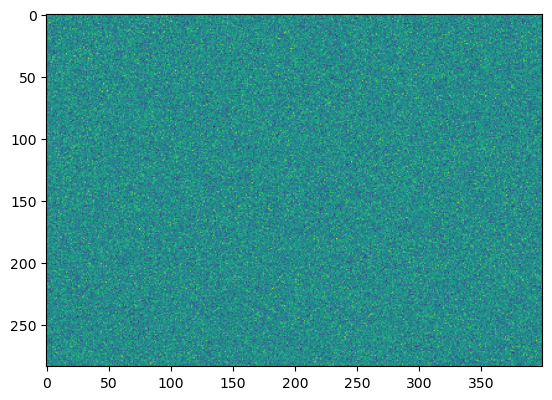

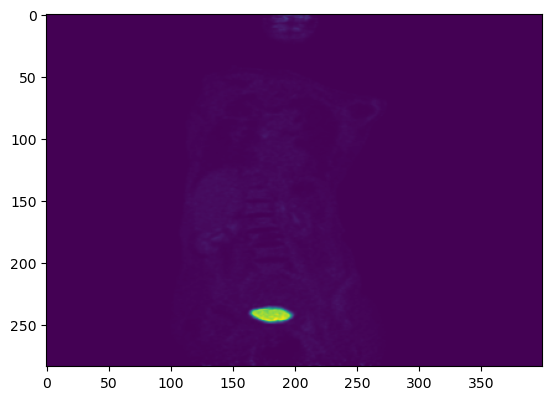

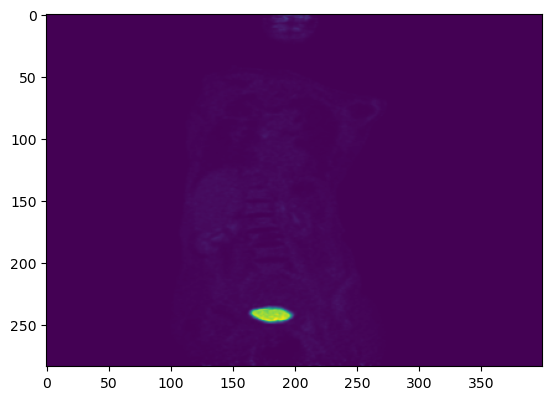

error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'imread'
> Overload resolution failed:
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object


In [ ]:
# import matplotlib.pyplot as plt
# NextDir = os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]
# nii_path = r"D:\New folder\FDG-PET-CT-Lesions/"+"/"+os.listdir(InitialDirectory)[i]+"/"+NextDir+"\PET.nii.gz"
# im = nimpa.getnii(nii_path)      # shape: (X,Y,Z)
# idx_y = mip_index(im, axis=1)   # coronal slices
# #for j in range(idx_y-10,idx_y+20):
# #im[j]
# TrainDest = 'D:/New folder/DatasetY/Training/'
# image_path = nii_path#.replace(".nii.gz","")
# image_path = image_path.replace('.nii.gz', ".jpg")
# image_format = ".jpg"
# #print(image_path)
# #norm = cv2.normalize(im, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)


# mean = 2
# var = 0.5
# sigma = var**0.5
# gauss = np.random.normal(mean,sigma,(im[:,j,:].shape[0],im[:,j,:].shape[1]))

# gauss = gauss.reshape(im[:,j,:].shape[0],im[:,j,:].shape[1])
# plt.imshow(gauss)
# plt.show()
# plt.imshow(im[:,j,:])
# plt.show()
# noisy_img = im[:,j,:] + gauss
# plt.imshow(noisy_img)
# plt.show()
# norm = (noisy_img - np.min(noisy_img)) / (np.max(noisy_img) - np.min(noisy_img))*300
# img = (norm).astype(float)
# plt.imshow(img)
# plt.show()
# #cv2.imwrite(image_path, img)

# #os.replace((image_path), TrainDest+(os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]+str(j)+".jpg"))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from niftypet import nimpa
import os
import pydicom as dicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import numpy as np
import cv2
def mip_index(volume, axis):
    # Sum intensity over the other two dimensions
    sums = np.sum(volume, axis=tuple(a for a in range(3) if a != axis))
    return int(np.argmax(sums))
InitialDirectory = r"D:\New folder\FDG-PET-CT-Lesions/"
for i in range(int(len(os.listdir(InitialDirectory))/2),len(os.listdir(InitialDirectory))-1):
#for i in range(0,1):
    NextDir = os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]
    nii_path = r"D:\New folder\FDG-PET-CT-Lesions/"+"/"+os.listdir(InitialDirectory)[i]+"/"+NextDir+"\PET.nii.gz"
    im = nimpa.getnii(nii_path)      # shape: (X,Y,Z)
    idx_y = mip_index(im, axis=1)   # coronal slices
    for j in range(idx_y-10,idx_y+20):
        #im[j]
        TrainDest = 'D:/New folder/DatasetY/Training/'
        image_path = nii_path#.replace(".nii.gz","")
        image_path = image_path.replace('.nii.gz', ".jpg")
        image_format = ".jpg"
        #print(image_path)
        #norm = cv2.normalize(im, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
        

        mean = 2
        var = 0.5
        sigma = var**0.5
        gauss = np.random.normal(mean,sigma,(im[:,j,:].shape[0],im[:,j,:].shape[1]))
        gauss = gauss.reshape(im[:,j,:].shape[0],im[:,j,:].shape[1])

        noisy_img = im[:,j,:] + gauss
        norm = (noisy_img - np.min(noisy_img)) / (np.max(noisy_img) - np.min(noisy_img))*350
        img = (norm).astype(float)
        cv2.imwrite(image_path, img)

        os.replace((image_path), TrainDest+(os.listdir(InitialDirectory+"/"+os.listdir(InitialDirectory)[i])[0]+str(j)+".jpg"))

d:\Conda\Lib\site-packages\miutil\cuinfo.py:12: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


(326, 400, 400)


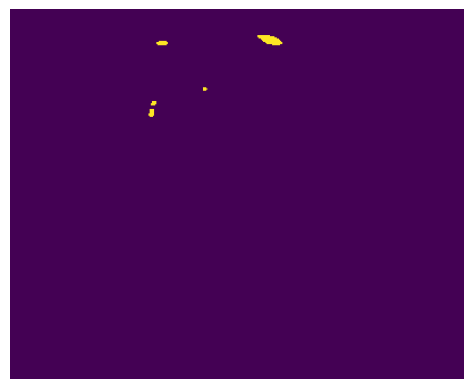

(326, 400, 400)


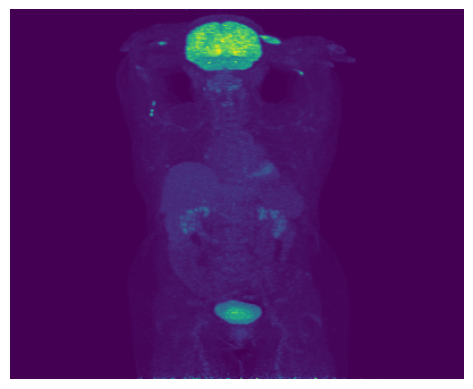

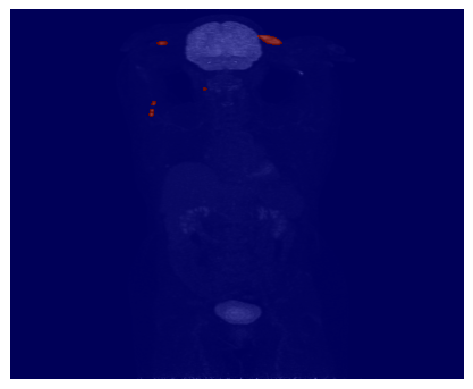

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from niftypet import nimpa
import os
import pydicom as dicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import numpy as np
import cv2


filename = "SEG.nii.gz"
dirs = os.listdir(r"D:\New folder\FDG-PET-CT-Lesions/")
#TrainDest = 'C:/Users/dorok/Downloads/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/'
#im = nimpa.getnii('C:/Users/dorok/Downloads/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/'+filename)#[:,70,:]
im = nimpa.getnii(r"D:\New folder\FDG-PET-CT-Lesions/"+dirs[0]+filename)
coronal = []
for i in range(0,400):
    coronal.append(im[:,i,:])
print(coronal)
print(im.shape)
#plt.imshow(im[:,200,:])
#plt.show()
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

#path = "test.tif"
#IM = io.imread(path)

IM_MAX= np.max(im, axis=1)
plt.imshow(IM_MAX)
plt.axis(False)
plt.show()

filename = "PET.nii.gz"

#TrainDest = 'C:/Users/dorok/Downloads/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/'
im = nimpa.getnii('C:/Users/dorok/Downloads/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/03-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-10445/'+filename)#[:,70,:]
print(im.shape)
#plt.imshow(im[:,200,:])
#plt.show()

import numpy as np
import matplotlib.pyplot as plt
from skimage import io

#path = "test.tif"
#IM = io.imread(path)
IM_MAX2= np.max(im, axis=1)

plt.imshow(IM_MAX2)
plt.axis(False)
plt.show()


plt.subplot(1,1,1)
plt.imshow(IM_MAX2, 'gray', interpolation='none')
plt.imshow(IM_MAX, 'jet', interpolation='none', alpha=0.7)
plt.axis(False)
plt.show()

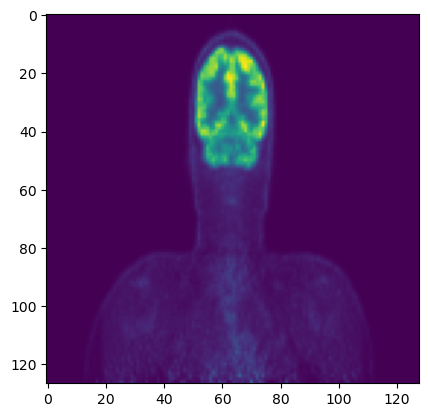

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from niftypet import nimpa
import os
import pydicom as dicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import numpy as np
import cv2

image_format = "jpg"

#for i in range(0,128):
#    filename = "PET_WHOLE_BODY_AC_20050710105845_1.nii"
#    image_path = 'D:/pet-radiomics-challenges/Training/Images/'+filename+'.gz'
#    TrainDest = 'D:/pet-radiomics-challenges/DatasetX/TrainingImages/'
#    im = nimpa.getnii('D:/pet-radiomics-challenges/Training/Images/'+filename+'.gz')[:,i,:]
#    image_path = image_path.replace('.nii.gz', image_format)
#    cv2.imwrite(image_path, im)         
#    os.replace((image_path), TrainDest+(filename+".gz").replace('.nii.gz', image_format))
filename = "PETCT_H&N_3D_20010815125724_11.nii.gz"

TrainDest = 'D:/pet-radiomics-challenges/DatasetX/TrainingImages/'
im = nimpa.getnii('D:/pet-radiomics-challenges/Training/Images/'+filename)[:,70,:]
plt.imshow(im)
plt.show()

In [14]:
initialName = "PETCT_H&N_3D_20010815125724_11"
filename = initialName+".nii.gz"
for i in range(10,75):
    
    TrainDest = 'D:/pet-radiomics-challenges/DatasetX/TrainingImages/'
    im = nimpa.getnii('D:/pet-radiomics-challenges/Training/Images/'+filename)[:,i,:]
    image_path = 'D:/pet-radiomics-challenges/Training/Images/'+filename
    image_path = image_path.replace('.nii.gz', ".jpg")
    image_format = ".jpg"
    print(image_path)
    #norm = cv2.normalize(im, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    norm = (im - np.min(im)) / (np.max(im) - np.min(im))*200
    cv2.imwrite(image_path, norm)

    os.replace((image_path), TrainDest+(filename.split(".jpg")[0]+str(i)+".jpg").replace('.nii.gz', image_format))

D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&N_3D_20010815125724_11.jpg
D:/pet-radiomics-challenges/Training/Images/PETCT_H&

In [49]:
abc = 'abcdefghijklmnopqrstuvwxyz'
initialName = "PET_AC_21_18780709111111_1"
for a in range(0,int(len(abc)/2)):
    #filename = "PET_WHOLE_BODY_AC_20050710105845_1.nii.gz"
    filename = initialName+abc[a]+".nii.gz"
    for i in range(10,80):
        
        TrainDest = 'D:/pet-radiomics-challenges/DatasetX/TrainingImages/'
        im = nimpa.getnii('D:/pet-radiomics-challenges/Training/Images/'+filename)[:,i,:]
        image_path = 'D:/pet-radiomics-challenges/Training/Images/'+filename
        image_path = image_path.replace('.nii.gz', ".jpg")
        image_format = ".jpg"
        print(image_path)
        #norm = cv2.normalize(im, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
        norm = (im - np.min(im)) / (np.max(im) - np.min(im))*200
        cv2.imwrite(image_path, norm)

        os.replace((image_path), TrainDest+(filename.split(".jpg")[0]+str(i)+".jpg").replace('.nii.gz', image_format))
for a in range(int(len(abc)/2),len(abc)):
    #filename = "PET_WHOLE_BODY_AC_20050710105845_1.nii.gz"
    filename = initialName+abc[a]+".nii.gz"
    for i in range(10,80):
        
        TrainDest = 'D:/pet-radiomics-challenges/DatasetY/TrainingImages/'
        im = nimpa.getnii('D:/pet-radiomics-challenges/Training/Images/'+filename)[:,i,:]
        image_path = 'D:/pet-radiomics-challenges/Training/Images/'+filename
        image_path = image_path.replace('.nii.gz', ".jpg")
        image_format = ".jpg"
        print(image_path)
        #norm = cv2.normalize(im, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
        norm = (im - np.min(im)) / (np.max(im) - np.min(im))*200
        cv2.imwrite(image_path, norm)

        os.replace((image_path), TrainDest+(filename.split(".jpg")[0]+str(i)+".jpg").replace('.nii.gz', image_format))
#plt.imshow(r"D:\pet-radiomics-challenges\DatasetX\TrainingImages\PET_WHOLE_BODY_AC_20050710105845_1.jpg")
#plt.show()

D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1a.jpg
D:/pet-radio

FileNotFoundError: No such file or no access: 'D:/pet-radiomics-challenges/Training/Images/PET_AC_21_18780709111111_1z.nii.gz'

In [10]:
import os
import pydicom
import torch
from torch.utils.data import Dataset
import numpy as np


class DicomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = []

        for root, _, filenames in os.walk(root_dir):
            for f in filenames:
                path = os.path.join(root, f)

                try:
                    dcm = pydicom.dcmread(path)
                    # Try getting pixel data; if it fails → not an image
                    _ = dcm.pixel_array
                    self.files.append(path)
                except Exception:
                    pass

        if len(self.files) == 0:
            raise RuntimeError("No DICOM files with pixel data were found.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        dicom = pydicom.dcmread(self.files[idx])
        img = dicom.pixel_array.astype(np.float32)

        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)
        img = torch.from_numpy(img).unsqueeze(0)

        if self.transform:
            img = self.transform(img)

        return img


In [6]:
import os
print(len(os.listdir("D:/pet-radiomics-challenges/DatasetX/TrainingImages/")))
print(len(os.listdir("D:/pet-radiomics-challenges/DatasetY/TrainingImages/")))

1045
999


In [228]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


batch_size = 4
image_size = 256  # try 128 or 256 for better quality
crop = 128
data_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(crop),
    transforms.ToTensor(),
    
    # Optional normalization (if you used it during training)
    transforms.Normalize((0.5,), (0.5,)),
    
])
X = ImageFolder("D:/New folder/DatasetX/", transform=data_transform)
Y = ImageFolder("D:/New folder/DatasetY/", transform=data_transform)
#dataset_X = DicomDataset("D:/pet-radiomics-challenges/Training/Training", transform=data_transform)
train_dl_X = DataLoader(Y, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
#dataset_Y = DicomDataset("D:/pet-radiomics-challenges/Test/Test", transform=data_transform)
train_dl_Y = DataLoader(X, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
#X = ImageFolder("C:/Users/dorok/Desktop/chatGPT/Diffusion model/flowers-102/", transform=data_transform)
#Y = ImageFolder("C:/Users/dorok/Desktop/chatGPT/datasets/", transform=data_transform)
#Y = ImageFolder("C:/Users/dorok/Desktop/chatGPT/datasets/PetImages/Train2/", transform=data_transform)

#X = ImageFolder("C:/Users/dorok/Desktop/chatGPT/datasets/PetImages/Train/", transform=data_transform)
#Y = ImageFolder("C:/Users/dorok/Desktop/chatGPT/datasets/img_align_celeba/Train2/", transform=data_transform)


#X = ImageFolder("D:/pet-radiomics-challenges/Test/", transform=data_transform)
#Y = ImageFolder("D:/pet-radiomics-challenges/Training/", transform=data_transform)

#train_dl_X = DataLoader(X, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
#train_dl_Y = DataLoader(Y, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)

In [229]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)


class CBAM(nn.Module):
    def __init__(self, channels):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x


In [230]:
discriminator_X = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),

    #nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    #nn.BatchNorm2d(512),
    #nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False),
    nn.AdaptiveAvgPool2d(1),   # forces 1x1 spatial output
    nn.Flatten(),
    nn.Sigmoid()
).to(device)

discriminator_Y = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),

    #nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    #nn.BatchNorm2d(512),
    #nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False),
    nn.AdaptiveAvgPool2d(1),   # forces 1x1 spatial output
    nn.Flatten(),
    nn.Sigmoid()
).to(device)


class SimpleGenerator(nn.Module):
    def __init__(self, in_ch=1, ngf=64):
        super().__init__()
        
        # encoder
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, ngf, 4, 2, 1),  
            nn.ReLU(True),
            CBAM(ngf),
            nn.Conv2d(ngf, ngf*2, 4, 2, 1),  
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            CBAM(ngf*2),
            nn.Conv2d(ngf*2, ngf*4, 4, 2, 1), 
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            CBAM(ngf*4),
            #nn.Conv2d(ngf*4, ngf*8, 4, 2, 1),  
            #nn.BatchNorm2d(ngf*8),
            #nn.ReLU(True),
        )
        # decoder
        self.dec = nn.Sequential(
            #nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1),
            #nn.BatchNorm2d(ngf*4),
            #nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, in_ch, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        #p = self.head(x)
        z = self.enc(x)
        out = self.dec(z)
        return out

generator_X = SimpleGenerator().to(device)
generator_Y = SimpleGenerator().to(device)

lr = 0.0002

#discriminator_X.load_state_dict(torch.load("DiscX.pth"))
#discriminator_Y.load_state_dict(torch.load("DiscY.pth"))
#generator_X.load_state_dict(torch.load("GenX.pth"))
#generator_Y.load_state_dict(torch.load("GenY.pth"))
opt_d_X = torch.optim.Adam(discriminator_X.parameters(), lr=lr, betas=(0.5, 0.999))
opt_d_Y = torch.optim.Adam(discriminator_Y.parameters(), lr=lr, betas=(0.5, 0.999))
opt_g_X = torch.optim.Adam(generator_X.parameters(), lr=lr, betas=(0.5, 0.999))
opt_g_Y = torch.optim.Adam(generator_Y.parameters(), lr=lr, betas=(0.5, 0.999))

In [231]:
def real_labels(n):
    return torch.ones(n, 1, device=device)

def fake_labels(n):
    return torch.zeros(n, 1, device=device)

# def train_discriminator(images_X, images_Y):
#     # images_X, images_Y are tensors on device
#     # X discriminator
#     opt_d_X.zero_grad()
#     real_preds = discriminator_X(images_X)
#     real_loss = F.binary_cross_entropy(real_preds, real_labels(real_preds.size(0)))

#     # fake from generator: map Y -> X_domain
#     with torch.no_grad():
#         fake_X = generator_X(images_Y)
#     fake_preds = discriminator_X(fake_X)
#     fake_loss = F.binary_cross_entropy(fake_preds, fake_labels(fake_preds.size(0)))

#     loss = real_loss + fake_loss
#     loss.backward()
#     opt_d_X.step()

#     # Y discriminator
#     opt_d_Y.zero_grad()
#     real_preds = discriminator_Y(images_Y)
#     real_loss = F.binary_cross_entropy(real_preds, real_labels(real_preds.size(0)))
def train_discriminator(images_X, images_Y):
    # ----------------------
    # Train Discriminator X
    # ----------------------
    opt_d_X.zero_grad()

    # Real X
    real_preds = discriminator_X(images_X)
    real_loss_X = F.binary_cross_entropy(real_preds, real_labels(real_preds.size(0)))

    # Fake X (G_X(Y))
    with torch.no_grad():
        fake_X = generator_X(images_Y)
    fake_preds = discriminator_X(fake_X)
    fake_loss_X = F.binary_cross_entropy(fake_preds, fake_labels(fake_preds.size(0)))

    loss_X = real_loss_X + fake_loss_X
    loss_X.backward()
    opt_d_X.step()

    # ----------------------
    # Train Discriminator Y
    # ----------------------
    opt_d_Y.zero_grad()

    # Real Y
    real_preds = discriminator_Y(images_Y)
    real_loss_Y = F.binary_cross_entropy(real_preds, real_labels(real_preds.size(0)))

    # Fake Y (G_Y(X))
    with torch.no_grad():
        fake_Y = generator_Y(images_X)
    fake_preds = discriminator_Y(fake_Y)
    fake_loss_Y = F.binary_cross_entropy(fake_preds, fake_labels(fake_preds.size(0)))

    loss_Y = real_loss_Y + fake_loss_Y
    loss_Y.backward()
    opt_d_Y.step()

    return loss_X.item(), loss_Y.item()
def train_generators(images_X, images_Y, lambda_cyc=1.0):
    # generators try to fool discriminators AND satisfy cycle-consistency
    opt_g_X.zero_grad()
    opt_g_Y.zero_grad()

    # X <- G_X(Y)
    fake_X = generator_X(images_Y)
    preds = discriminator_X(fake_X)
    adv_loss_X = F.binary_cross_entropy(preds, real_labels(preds.size(0)))

    # Y <- G_Y(X)
    fake_Y = generator_Y(images_X)
    preds = discriminator_Y(fake_Y)
    adv_loss_Y = F.binary_cross_entropy(preds, real_labels(preds.size(0)))

    # cycle: X -> (G_Y) -> back to X
    rec_X = generator_Y(fake_X)
    rec_Y = generator_X(fake_Y)
    cyc_loss = F.l1_loss(rec_X, images_X) + F.l1_loss(rec_Y, images_Y)

    lossG = adv_loss_X + adv_loss_Y + lambda_cyc * cyc_loss
    lossG.backward()

    opt_g_X.step()
    opt_g_Y.step()

    return (adv_loss_X.item() + adv_loss_Y.item(), cyc_loss.item())


In [232]:



# discriminator_X = nn.Sequential(
#     nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
#     nn.BatchNorm2d(64),
#     nn.LeakyReLU(0.2, inplace=True),

#     nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
#     nn.BatchNorm2d(128),
#     nn.LeakyReLU(0.2, inplace=True),

#     nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
#     nn.BatchNorm2d(256),
#     nn.LeakyReLU(0.2, inplace=True),

#     #nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
#     #nn.BatchNorm2d(512),
#     #nn.LeakyReLU(0.2, inplace=True),

#     nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False),
#     nn.AdaptiveAvgPool2d(1),   # forces 1x1 spatial output
#     nn.Flatten(),
#     nn.Sigmoid()
# ).to(device)

# # You can reuse same arch for Y discriminator
# #discriminator_Y = nn.Sequential(*[module for module in discriminator_X]).to(device)  # shallow copy not ideal but okay here
# import copy
# discriminator_Y = copy.deepcopy(discriminator_X)
# class SimpleGenerator(nn.Module):
#     def __init__(self, in_ch=3, ngf=64):
#         super().__init__()
#         # encoder
#         self.enc = nn.Sequential(
#             nn.Conv2d(in_ch, ngf, 4, 2, 1),  
#             nn.ReLU(True),
#             nn.Conv2d(ngf, ngf*2, 4, 2, 1),  
#             nn.BatchNorm2d(ngf*2),
#             nn.ReLU(True),
#             nn.Conv2d(ngf*2, ngf*4, 4, 2, 1), 
#             nn.BatchNorm2d(ngf*4),
#             nn.ReLU(True),
#             nn.Conv2d(ngf*4, ngf*8, 4, 2, 1),  
#             nn.BatchNorm2d(ngf*8),
#             nn.ReLU(True),
#         )
#         # decoder
#         self.dec = nn.Sequential(
#             nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1),
#             nn.BatchNorm2d(ngf*4),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1),
#             nn.BatchNorm2d(ngf*2),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1),
#             nn.BatchNorm2d(ngf),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(ngf, in_ch, 4, 2, 1),
#             nn.Tanh()
#         )

#     def forward(self, x):
#         z = self.enc(x)
#         out = self.dec(z)
#         return out

# generator_X = SimpleGenerator().to(device)
# generator_Y = SimpleGenerator().to(device)

# lr = 0.0002
# opt_d_X = torch.optim.Adam(discriminator_X.parameters(), lr=lr, betas=(0.5, 0.999))
# opt_d_Y = torch.optim.Adam(discriminator_Y.parameters(), lr=lr, betas=(0.5, 0.999))
# opt_g_X = torch.optim.Adam(generator_X.parameters(), lr=lr, betas=(0.5, 0.999))
# opt_g_Y = torch.optim.Adam(generator_Y.parameters(), lr=lr, betas=(0.5, 0.999))

# def real_labels(n):
#     return torch.ones(n, 1, device=device)

# def fake_labels(n):
#     return torch.zeros(n, 1, device=device)

# def train_discriminator(images_X, images_Y):
#     # images_X, images_Y are tensors on device
#     # X discriminator
#     opt_d_X.zero_grad()
#     real_preds = discriminator_X(images_X)
#     real_loss = F.binary_cross_entropy(real_preds, real_labels(real_preds.size(0)))

#     # fake from generator: map Y -> X_domain
#     with torch.no_grad():
#         fake_X = generator_X(images_Y)
#     fake_preds = discriminator_X(fake_X)
#     fake_loss = F.binary_cross_entropy(fake_preds, fake_labels(fake_preds.size(0)))

#     loss = real_loss + fake_loss
#     loss.backward()
#     opt_d_X.step()

#     # Y discriminator
#     opt_d_Y.zero_grad()
#     real_preds = discriminator_Y(images_Y)
#     real_loss = F.binary_cross_entropy(real_preds, real_labels(real_preds.size(0)))

#     with torch.no_grad():
#         fake_Y = generator_Y(images_X)
#     fake_preds = discriminator_Y(fake_Y)
#     fake_loss = F.binary_cross_entropy(fake_preds, fake_labels(fake_preds.size(0)))

#     loss2 = real_loss + fake_loss
#     loss2.backward()
#     opt_d_Y.step()

#     return (loss.item(), loss2.item())

# def train_generators(images_X, images_Y, lambda_cyc=1.0):
#     # generators try to fool discriminators AND satisfy cycle-consistency
#     opt_g_X.zero_grad()
#     opt_g_Y.zero_grad()

#     # X <- G_X(Y)
#     fake_X = generator_X(images_Y)
#     preds = discriminator_X(fake_X)
#     adv_loss_X = F.binary_cross_entropy(preds, real_labels(preds.size(0)))

#     # Y <- G_Y(X)
#     fake_Y = generator_Y(images_X)
#     preds = discriminator_Y(fake_Y)
#     adv_loss_Y = F.binary_cross_entropy(preds, real_labels(preds.size(0)))

#     # cycle: X -> (G_Y) -> back to X
#     rec_X = generator_Y(fake_X)
#     rec_Y = generator_X(fake_Y)
#     cyc_loss = F.l1_loss(rec_X, images_X) + F.l1_loss(rec_Y, images_Y)

#     lossG = adv_loss_X + adv_loss_Y + lambda_cyc * cyc_loss
#     lossG.backward()

#     opt_g_X.step()
#     opt_g_Y.step()

#     return (adv_loss_X.item() + adv_loss_Y.item(), cyc_loss.item())




In [ ]:

epochs = 100
for epoch in range(epochs):
    for batch_X, batch_Y in zip(train_dl_X, train_dl_Y):
        images_X,_ = batch_X
        images_Y,_ = batch_Y

        images_X = images_X.to(device)
        images_Y = images_Y.to(device)

        d_losses = train_discriminator(images_X, images_Y)
        g_losses = train_generators(images_X, images_Y)

    print(f"Epoch {epoch+1}/{epochs} ; D_losses={d_losses} ; G_losses={g_losses}")
    import torch
    from torchvision import transforms
    import matplotlib.pyplot as plt

    generator_Y.eval()  # maps X -> Y

    # take one batch (or just one image) from the food dataset
    sample_X,_ = next(iter(train_dl_X))
    sample_X = sample_X.to(device)

    # use only one image
    img_X = sample_X[0:1]  

    # generate translated image (food -> flower style)
    with torch.no_grad():
        fake_Y = generator_Y(img_X)

    # helper to denormalize tensor for plotting
    def denorm(t):
        out = (t.clamp(-1, 1) + 1) / 2
        return out.cpu().permute(0, 2, 3, 1).squeeze()

    # visualize
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(denorm(img_X))
    plt.title("Original X (Noise)")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(denorm(fake_Y))
    plt.title("Generated Y (No Noise)")
    plt.axis("off")

    plt.show()
    generator_X.eval()  # maps Y -> X

    sample_Y,_ = next(iter(train_dl_Y))
    sample_Y = sample_Y.to(device)
    img_Y = sample_Y[0:1]

    with torch.no_grad():
        fake_X = generator_X(img_Y)

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(denorm(img_Y))
    plt.title("Original Y (No Noise)")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(denorm(fake_X))
    plt.title("Generated X (Noise)")
    plt.axis("off")

    plt.show()


In [209]:
plt.imshow("Test.jpg")
plt.show()

NameError: name 'plt' is not defined

In [7]:
torch.save(generator_X.state_dict(), 'GenX.pth')    
torch.save(generator_Y.state_dict(), 'GenY.pth')    
torch.save(discriminator_X.state_dict(), 'DiscX.pth')    
torch.save(discriminator_Y.state_dict(), 'DiscY.pth')     

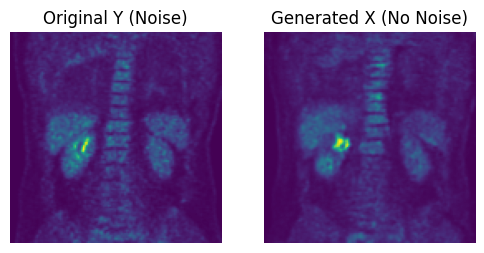

In [17]:


sample_X,_ = next(iter(train_dl_X))
sample_X = sample_X.to(device)
img_X = sample_X[3:4]

with torch.no_grad():
    fake_X = generator_Y(img_X)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(denorm(img_X))
plt.title("Original Y (Noise)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denorm(fake_X))
plt.title("Generated X (No Noise)")
plt.axis("off")

plt.show()

In [ ]:
import torch 
from torchvision import transforms
import matplotlib.pyplot as plt

# put model in eval mode
generator_Y.eval()  # maps X -> Y

# take one batch (or just one image) from the food dataset
sample_X, _ = next(iter(train_dl_X))
sample_X = sample_X.to(device)

# use only one image
img_X = sample_X[0:1]   

# generate translated image (food -> flower style)
with torch.no_grad():
    fake_Y = generator_Y(img_X)

# helper to denormalize tensor for plotting
def denorm(t):
    out = (t.clamp(-1, 1) + 1) / 2
    return out.cpu().permute(0, 2, 3, 1).squeeze()

# visualize
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(denorm(img_X))
plt.title("Original X (Food)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denorm(fake_Y))
plt.title("Generated Y (Art)")
plt.axis("off")

plt.show()


TypeError: pic should be PIL Image or ndarray. Got <class 'torchvision.transforms.transforms.Grayscale'>

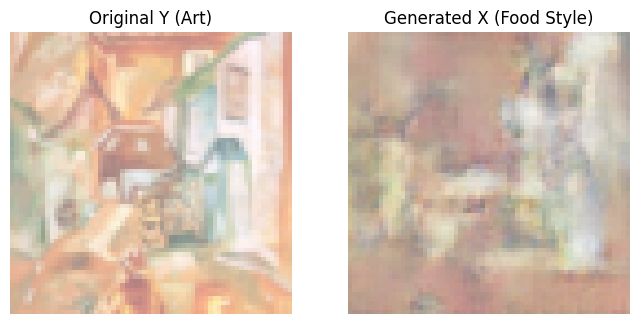

In [ ]:
generator_X.eval()  # maps Y -> X

sample_Y, _ = next(iter(train_dl_Y))
sample_Y = sample_Y.to(device)
img_Y = sample_Y[0:1]

with torch.no_grad():
    fake_X = generator_X(img_Y)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(denorm(img_Y))
plt.title("Original Y (Art)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denorm(fake_X))
plt.title("Generated X (Food Style)")
plt.axis("off")

plt.show()
